<a href="https://www.kaggle.com/code/gonnzaga/arvorededecis-o-florestaaleat-riaeboosting?scriptVersionId=354528710" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

# SVM, Árvore de Decisão, Floresta Aleatória e Boosting — Dataset IRIS

**Aluno:** Victor Gabriel Figueira Gonzaga

Objetivo: rodar os modelos de SVM, Árvore de Decisão, Floresta Aleatória e Boosting no dataset IRIS, **com e sem GridSearchCV**, e analisar qual apresenta melhor **sensibilidade (recall)** e **acurácia**.

## 1. Importações e carregamento dos dados

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import accuracy_score, recall_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

RANDOM_STATE = 42

df = pd.read_csv("/kaggle/input/datasets/menegidio/iris-species/Iris.csv")
df.head()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


In [2]:
print(df.shape)
print(df["Species"].value_counts())
df.describe()

(150, 6)
Species
Iris-setosa        50
Iris-versicolor    50
Iris-virginica     50
Name: count, dtype: int64


,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,75.500000,5.843333,3.054000,3.758667,1.198667
std,43.445368,0.828066,0.433594,1.764420,0.763161
min,1.000000,4.300000,2.000000,1.000000,0.100000
25%,38.250000,5.100000,2.800000,1.600000,0.300000
50%,75.500000,5.800000,3.000000,4.350000,1.300000
75%,112.750000,6.400000,3.300000,5.100000,1.800000
max,150.000000,7.900000,4.400000,6.900000,2.500000


## 2. Preparação

Removemos a coluna `Id` (não é uma característica da flor) e separamos 70% para treino e 30% para teste, de forma estratificada para manter as 3 classes balanceadas.

In [3]:
X = df.drop(columns=["Id", "Species"])
y = df["Species"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, stratify=y, random_state=RANDOM_STATE
)
print("Treino:", X_train.shape, "| Teste:", X_test.shape)

Treino: (105, 4) | Teste: (45, 4)


## 3. Definição dos modelos e das grades de hiperparâmetros

O SVM é sensível à escala das variáveis, por isso usa um `Pipeline` com `StandardScaler`. Os modelos baseados em árvore não precisam de padronização.

In [4]:
modelos = {
    "SVM": (
        Pipeline([("scaler", StandardScaler()), ("clf", SVC(random_state=RANDOM_STATE))]),
        {
            "clf__C": [0.1, 1, 10, 100],
            "clf__kernel": ["linear", "rbf", "poly"],
            "clf__gamma": ["scale", 0.01, 0.1, 1],
        },
    ),
    "Árvore de Decisão": (
        DecisionTreeClassifier(random_state=RANDOM_STATE),
        {
            "criterion": ["gini", "entropy"],
            "max_depth": [None, 2, 3, 4, 5],
            "min_samples_split": [2, 5, 10],
            "min_samples_leaf": [1, 2, 4],
        },
    ),
    "Floresta Aleatória": (
        RandomForestClassifier(random_state=RANDOM_STATE),
        {
            "n_estimators": [50, 100, 200],
            "max_depth": [None, 3, 5],
            "min_samples_split": [2, 5],
            "max_features": ["sqrt", "log2"],
        },
    ),
    "Boosting (Gradient Boosting)": (
        GradientBoostingClassifier(random_state=RANDOM_STATE),
        {
            "n_estimators": [50, 100, 200],
            "learning_rate": [0.01, 0.1, 0.5],
            "max_depth": [1, 2, 3],
        },
    ),
}

## 4. Treinamento: sem e com GridSearchCV

- **Sem GridSearchCV:** hiperparâmetros padrão do scikit-learn.
- **Com GridSearchCV:** busca em grade com validação cruzada estratificada de 5 folds, otimizando a acurácia.

A **sensibilidade** é o recall. Como o problema tem 3 classes, usamos a média macro (média do recall de cada espécie).

In [5]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

resultados = []
predicoes = {}
melhores_params = {}

def avaliar(nome, config, modelo):
    y_pred = modelo.predict(X_test)
    predicoes[(nome, config)] = y_pred
    cv_acc = cross_val_score(modelo, X, y, cv=cv, scoring="accuracy").mean()
    cv_rec = cross_val_score(modelo, X, y, cv=cv, scoring="recall_macro").mean()
    resultados.append({
        "Modelo": nome,
        "Configuração": config,
        "Acurácia (teste)": accuracy_score(y_test, y_pred),
        "Sensibilidade (teste)": recall_score(y_test, y_pred, average="macro"),
        "Acurácia (CV 5-fold)": cv_acc,
        "Sensibilidade (CV 5-fold)": cv_rec,
    })

for nome, (estimador, grade) in modelos.items():
    # Sem GridSearchCV
    base = estimador.fit(X_train, y_train)
    avaliar(nome, "Sem GridSearchCV", base)

    # Com GridSearchCV
    grid = GridSearchCV(estimador, grade, cv=cv, scoring="accuracy", n_jobs=-1)
    grid.fit(X_train, y_train)
    melhores_params[nome] = grid.best_params_
    avaliar(nome, "Com GridSearchCV", grid.best_estimator_)
    print(f"{nome} -> melhores parâmetros: {grid.best_params_}")

SVM -> melhores parâmetros: {'clf__C': 100, 'clf__gamma': 'scale', 'clf__kernel': 'linear'}
Árvore de Decisão -> melhores parâmetros: {'criterion': 'gini', 'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 10}
Floresta Aleatória -> melhores parâmetros: {'max_depth': None, 'max_features': 'sqrt', 'min_samples_split': 5, 'n_estimators': 50}
Boosting (Gradient Boosting) -> melhores parâmetros: {'learning_rate': 0.01, 'max_depth': 1, 'n_estimators': 50}


## 5. Resultados

In [6]:
tabela = pd.DataFrame(resultados)
tabela.style.format({c: "{:.4f}" for c in tabela.columns[2:]})

,Modelo,Configuração,Acurácia (teste),Sensibilidade (teste),Acurácia (CV 5-fold),Sensibilidade (CV 5-fold)
0,SVM,Sem GridSearchCV,0.9333,0.9333,0.9600,0.9600
1,SVM,Com GridSearchCV,0.9333,0.9333,0.9600,0.9600
2,Árvore de Decisão,Sem GridSearchCV,0.9333,0.9333,0.9533,0.9533
3,Árvore de Decisão,Com GridSearchCV,0.9333,0.9333,0.9600,0.9600
4,Floresta Aleatória,Sem GridSearchCV,0.8889,0.8889,0.9467,0.9467
5,Floresta Aleatória,Com GridSearchCV,0.8889,0.8889,0.9600,0.9600
6,Boosting (Gradient Boosting),Sem GridSearchCV,0.9333,0.9333,0.9533,0.9533
7,Boosting (Gradient Boosting),Com GridSearchCV,0.9333,0.9333,0.9333,0.9333


In [7]:
for nome in modelos:
    for config in ["Sem GridSearchCV", "Com GridSearchCV"]:
        print("=" * 60)
        print(f"{nome} — {config}")
        print(classification_report(y_test, predicoes[(nome, config)], digits=4))

SVM — Sem GridSearchCV
                 precision    recall  f1-score   support

    Iris-setosa     1.0000    1.0000    1.0000        15
Iris-versicolor     0.8750    0.9333    0.9032        15
 Iris-virginica     0.9286    0.8667    0.8966        15

       accuracy                         0.9333        45
      macro avg     0.9345    0.9333    0.9333        45
   weighted avg     0.9345    0.9333    0.9333        45

SVM — Com GridSearchCV
                 precision    recall  f1-score   support

    Iris-setosa     1.0000    1.0000    1.0000        15
Iris-versicolor     0.8333    1.0000    0.9091        15
 Iris-virginica     1.0000    0.8000    0.8889        15

       accuracy                         0.9333        45
      macro avg     0.9444    0.9333    0.9327        45
   weighted avg     0.9444    0.9333    0.9327        45

Árvore de Decisão — Sem GridSearchCV
                 precision    recall  f1-score   support

    Iris-setosa     1.0000    1.0000    1.0000        1

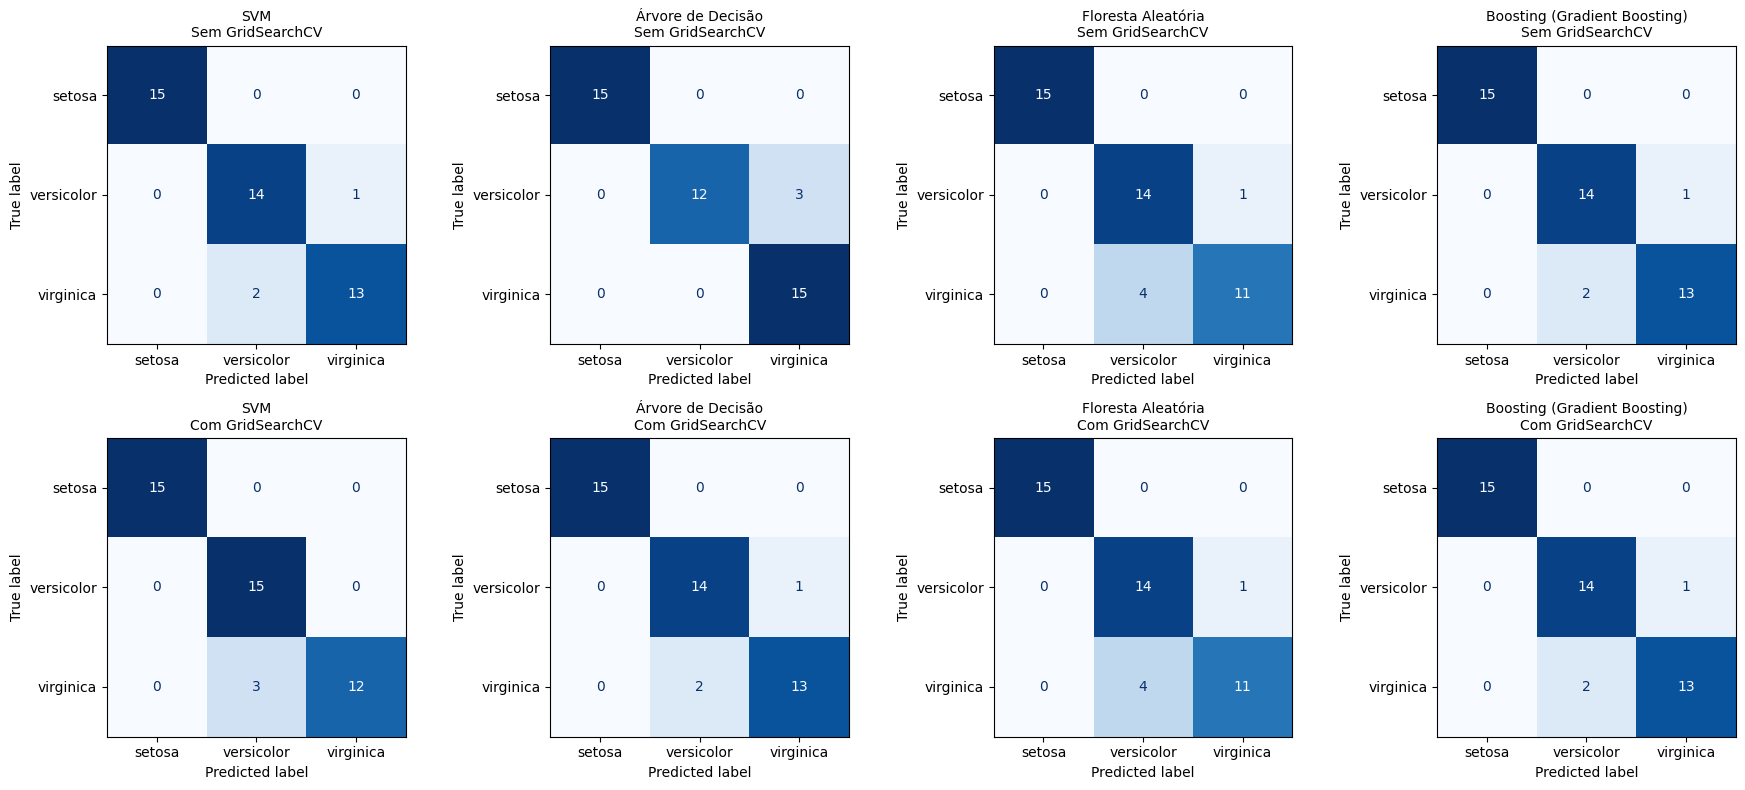

In [8]:
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
for j, nome in enumerate(modelos):
    for i, config in enumerate(["Sem GridSearchCV", "Com GridSearchCV"]):
        ConfusionMatrixDisplay.from_predictions(
            y_test, predicoes[(nome, config)], ax=axes[i, j], cmap="Blues", colorbar=False,
            display_labels=["setosa", "versicolor", "virginica"],
        )
        axes[i, j].set_title(f"{nome}\n{config}", fontsize=10)
plt.tight_layout()
plt.show()

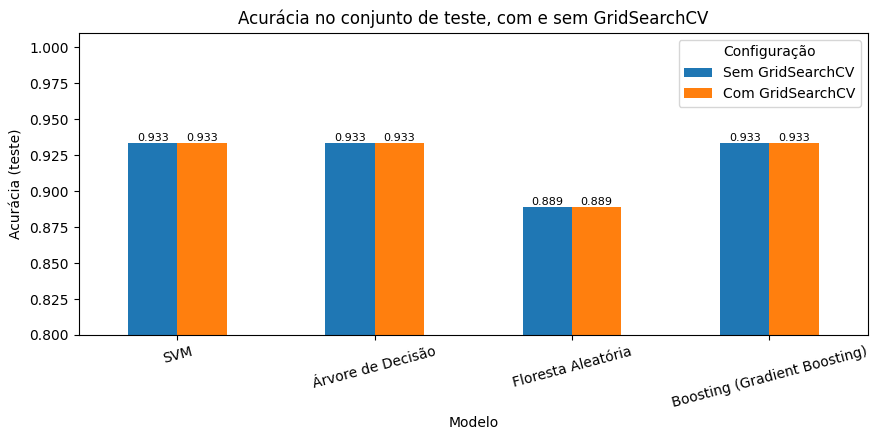

In [9]:
pivot = tabela.pivot(index="Modelo", columns="Configuração", values="Acurácia (teste)").loc[list(modelos)]
pivot = pivot[["Sem GridSearchCV", "Com GridSearchCV"]]
ax = pivot.plot(kind="bar", figsize=(9, 4.5), rot=15)
ax.set_ylim(0.8, 1.01)
ax.set_ylabel("Acurácia (teste)")
ax.set_title("Acurácia no conjunto de teste, com e sem GridSearchCV")
for c in ax.containers:
    ax.bar_label(c, fmt="%.3f", fontsize=8)
plt.tight_layout()
plt.show()

## 6. Análise

**Acurácia e sensibilidade no conjunto de teste (45 amostras):**

| Modelo | Sem GridSearchCV | Com GridSearchCV |
|---|---|---|
| SVM | 0,9333 | 0,9333 |
| Árvore de Decisão | 0,9333 | 0,9333 |
| Floresta Aleatória | 0,8889 | 0,8889 |
| Boosting | 0,9333 | 0,9333 |

Como as três classes têm exatamente a mesma quantidade de amostras, a sensibilidade macro coincide numericamente com a acurácia; por isso as duas métricas aparecem com os mesmos valores.

**Qual modelo foi melhor?**

- No teste, **SVM, Árvore de Decisão e Boosting empataram** com 93,33% de acurácia e de sensibilidade (3 erros em 45). A Floresta Aleatória ficou um pouco abaixo, com 88,89% (5 erros).
- Na validação cruzada de 5 folds sobre o dataset inteiro, que é uma estimativa mais estável por não depender de uma única divisão, o **SVM foi o mais consistente**: 96,00% tanto com os parâmetros padrão quanto com os ajustados. Árvore de Decisão e Floresta Aleatória também chegaram a 96,00%, mas só depois do GridSearchCV.
- Considerando as duas avaliações, o **SVM é o modelo com melhor desempenho geral** em acurácia e sensibilidade, embora a diferença para os demais seja pequena (1 ou 2 flores).

**Sensibilidade por classe:**

- *Iris-setosa* teve sensibilidade de 100% em todos os modelos, pois é linearmente separável das outras duas.
- Todos os erros aconteceram entre *versicolor* e *virginica*, cujas medidas de pétala se sobrepõem. A sensibilidade nessas classes variou de 73% a 100% conforme o modelo.

**Efeito do GridSearchCV:**

- No conjunto de teste, o GridSearchCV **não alterou a acurácia de nenhum modelo**. Ele mudou apenas quais flores foram classificadas errado (por exemplo, o SVM ajustado passou a acertar todas as versicolor, mas errou uma virginica a mais).
- Na validação cruzada houve ganho pequeno para a Árvore de Decisão (95,33% → 96,00%) e para a Floresta Aleatória (94,67% → 96,00%), nenhuma mudança no SVM e uma **piora no Boosting** (95,33% → 93,33%), cuja grade escolheu um modelo muito simples (`max_depth=1`, `learning_rate=0.01`).
- Isso mostra que o IRIS é um dataset pequeno e fácil: os parâmetros padrão já ficam perto do limite possível, então a busca em grade traz pouco ou nenhum ganho, e com apenas 105 amostras de treino a escolha do "melhor" parâmetro tem bastante variação.

**Conclusão:** o SVM apresentou a melhor combinação de acurácia e sensibilidade, seguido de perto pela Árvore de Decisão e pelo Boosting. O GridSearchCV não trouxe melhora relevante neste dataset.